# ICS1512 – Machine Learning Algorithms Laboratory
## Experiment 3: Regression Analysis using Linear and Regularized Models

**Student Name:** Nathaniel Christian
**Register Number:** 3122247001037
**Faculty:** Dr. Poreddy Ajay Kumar Reddy
**Academic Year:** 2026–2027 (odd)
**GitHub Repository:** https://github.com/N4T-C/ML-3122247001037

**Objective:** To implement Linear, Ridge, Lasso and Elastic Net regression models for
predicting the sanctioned loan amount (`LoanAmount`), evaluate their performance using
multiple metrics, visualize model behaviour, and analyze overfitting, underfitting and
bias–variance characteristics.

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import platform

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

import sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Environment / Version Information

In [2]:
print("Python version    :", platform.python_version())
print("pandas version    :", pd.__version__)
print("numpy version     :", np.__version__)
print("scikit-learn ver. :", sklearn.__version__)
print("matplotlib version:", matplotlib.__version__)
print("seaborn version   :", sns.__version__)

Python version    : 3.12.3
pandas version    : 3.0.2
numpy version     : 2.4.4
scikit-learn ver. : 1.8.0
matplotlib version: 3.10.8
seaborn version   : 0.13.2


## 3. Load Dataset

The Loan Prediction dataset is loaded from the repository path
`datasets/loan_prediction/train.csv` (relative path `../datasets/loan_prediction/train.csv`
from the `assign3/` folder).

In [3]:
DATA_PATH = "../datasets/loan_prediction/train.csv"
df = pd.read_csv(DATA_PATH)
print("Dataset loaded from:", DATA_PATH)
df.head()

Dataset loaded from: ../datasets/loan_prediction/train.csv


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 4. Dataset Inspection

In [4]:
print("Shape of dataset:", df.shape)
print()
print("Column data types:")
print(df.dtypes)

Shape of dataset: (614, 13)

Column data types:
Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())

Missing values per column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Total missing values: 149


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Loan_ID,614,614,LP001002,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,601,2,Male,489,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Married,611,2,Yes,398,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,599,4,0,345,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,614,2,Graduate,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Self_Employed,582,2,No,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ApplicantIncome,614.0,NaN,NaN,NaN,5403.459283,6109.041673,150.0,2877.5,3812.5,5795.0,81000.0
CoapplicantIncome,614.0,NaN,NaN,NaN,1621.245798,2926.248369,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,NaN,NaN,NaN,146.412162,85.587325,9.0,100.0,128.0,168.0,700.0
Loan_Amount_Term,600.0,NaN,NaN,NaN,342.0,65.12041,12.0,360.0,360.0,360.0,480.0


## 5. Dataset Description

- **Target variable:** `LoanAmount` (continuous, sanctioned loan amount in thousands)
- **Identifier column:** `Loan_ID` (dropped — not predictive)
- **Numerical features:** `ApplicantIncome`, `CoapplicantIncome`, `Loan_Amount_Term`,
  `Credit_History`
- **Categorical features:** `Gender`, `Married`, `Dependents`, `Education`,
  `Self_Employed`, `Property_Area`, `Loan_Status`

Rows with a missing target (`LoanAmount`) are dropped, since the target cannot be
imputed without leaking information / fabricating labels.

In [7]:
TARGET = "LoanAmount"

# Drop non-predictive identifier column
df = df.drop(columns=["Loan_ID"])

# Drop rows with missing target value
before = df.shape[0]
df = df.dropna(subset=[TARGET]).reset_index(drop=True)
after = df.shape[0]
print(f"Rows before dropping missing target: {before}")
print(f"Rows after dropping missing target : {after}")
print(f"Rows dropped (missing {TARGET})     : {before - after}")

Rows before dropping missing target: 614
Rows after dropping missing target : 592
Rows dropped (missing LoanAmount)     : 22


## 6. Reusable Plot Formatting Configuration

A global Matplotlib configuration is applied so that every figure in this notebook uses
a consistent Times-New-Roman-style serif font, 15pt text, bold 15pt axis labels and
15pt legends. (Liberation Serif, a metric-compatible substitute for Times New Roman, is
registered and used as a fallback on systems where Times New Roman itself is not
installed, e.g. Linux lab machines.)

In [8]:
# Register Liberation Serif (metric-compatible with Times New Roman) if available
for _font_path in fm.findSystemFonts():
    if "LiberationSerif" in _font_path:
        fm.fontManager.addfont(_font_path)

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
    "font.size": 15,
    "axes.titlesize": 15,
    "axes.labelsize": 15,
    "axes.labelweight": "bold",
    "legend.fontsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "figure.titlesize": 16,
})

print("Global plot formatting configured: Times New Roman style, 15pt, bold axis labels.")

Global plot formatting configured: Times New Roman style, 15pt, bold axis labels.


## 7. Reusable EDA Function (12-Subplot Consolidated Summary)

The function `create_eda_summary()` produces **one consolidated figure containing 12
subplots**, covering the target variable and all key numerical/categorical features of
the Loan Prediction dataset. The figure is displayed inline and exported as
`eda_summary.eps` at 600 DPI.

In [9]:
def create_eda_summary(data, target_column, save_path="eda_summary.eps", dpi=600):
    """
    Generate a single consolidated EDA figure with 12 subplots summarising the
    Loan Prediction dataset, and export it as a 600 DPI EPS file.

    Parameters
    ----------
    data : pd.DataFrame
        The (preprocessed-for-EDA) dataframe containing the raw feature columns.
    target_column : str
        Name of the continuous target column (LoanAmount).
    save_path : str
        Output path for the EPS export.
    dpi : int
        Export resolution in dots per inch.

    Returns
    -------
    matplotlib.figure.Figure
    """
    fig, axes = plt.subplots(4, 3, figsize=(20, 22))
    axes = axes.flatten()

    # 1. Target variable distribution (histogram + KDE)
    sns.histplot(data[target_column].dropna(), kde=True, ax=axes[0], color="#4C72B0")
    axes[0].set_title("1. Target Variable Distribution (LoanAmount)")
    axes[0].set_xlabel("LoanAmount")
    axes[0].set_ylabel("Frequency")

    # 2. ApplicantIncome distribution
    sns.histplot(data["ApplicantIncome"].dropna(), kde=True, ax=axes[1], color="#55A868")
    axes[1].set_title("2. Applicant Income Distribution")
    axes[1].set_xlabel("ApplicantIncome")
    axes[1].set_ylabel("Frequency")

    # 3. CoapplicantIncome distribution
    sns.histplot(data["CoapplicantIncome"].dropna(), kde=True, ax=axes[2], color="#C44E52")
    axes[2].set_title("3. Coapplicant Income Distribution")
    axes[2].set_xlabel("CoapplicantIncome")
    axes[2].set_ylabel("Frequency")

    # 4. Loan_Amount_Term distribution
    sns.countplot(x=data["Loan_Amount_Term"].dropna(), ax=axes[3], color="#8172B2")
    axes[3].set_title("4. Loan Amount Term Distribution")
    axes[3].set_xlabel("Loan_Amount_Term")
    axes[3].set_ylabel("Count")
    axes[3].tick_params(axis="x", rotation=45)

    # 5. LoanAmount distribution (boxplot, to highlight spread/outliers)
    sns.boxplot(x=data[target_column].dropna(), ax=axes[4], color="#CCB974")
    axes[4].set_title("5. Loan Amount Distribution (Boxplot)")
    axes[4].set_xlabel("LoanAmount")

    # 6. Credit_History distribution
    sns.countplot(x=data["Credit_History"].dropna(), ax=axes[5], color="#64B5CD")
    axes[5].set_title("6. Credit History Distribution")
    axes[5].set_xlabel("Credit_History")
    axes[5].set_ylabel("Count")

    # 7. Gender distribution
    sns.countplot(x=data["Gender"].dropna(), ax=axes[6], color="#4C72B0")
    axes[6].set_title("7. Gender Distribution")
    axes[6].set_xlabel("Gender")
    axes[6].set_ylabel("Count")

    # 8. Married distribution
    sns.countplot(x=data["Married"].dropna(), ax=axes[7], color="#55A868")
    axes[7].set_title("8. Married Distribution")
    axes[7].set_xlabel("Married")
    axes[7].set_ylabel("Count")

    # 9. Education distribution
    sns.countplot(x=data["Education"].dropna(), ax=axes[8], color="#C44E52")
    axes[8].set_title("9. Education Distribution")
    axes[8].set_xlabel("Education")
    axes[8].set_ylabel("Count")
    axes[8].tick_params(axis="x", rotation=15)

    # 10. Self_Employed distribution
    sns.countplot(x=data["Self_Employed"].dropna(), ax=axes[9], color="#8172B2")
    axes[9].set_title("10. Self Employed Distribution")
    axes[9].set_xlabel("Self_Employed")
    axes[9].set_ylabel("Count")

    # 11. Property_Area distribution
    sns.countplot(x=data["Property_Area"].dropna(), ax=axes[10], color="#CCB974")
    axes[10].set_title("11. Property Area Distribution")
    axes[10].set_xlabel("Property_Area")
    axes[10].set_ylabel("Count")

    # 12. Loan_Status distribution
    sns.countplot(x=data["Loan_Status"].dropna(), ax=axes[11], color="#64B5CD")
    axes[11].set_title("12. Loan Status Distribution")
    axes[11].set_xlabel("Loan_Status")
    axes[11].set_ylabel("Count")

    fig.suptitle("Consolidated Exploratory Data Analysis Summary — Loan Prediction Dataset",
                 fontsize=18, fontweight="bold", y=1.01)
    fig.tight_layout()
    fig.savefig(save_path, format="eps", dpi=dpi, bbox_inches="tight")
    print(f"Consolidated EDA figure saved to '{save_path}' at {dpi} DPI.")
    return fig

## 8. Generate the 12-Plot Consolidated EDA Figure

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Consolidated EDA figure saved to 'eda_summary.eps' at 600 DPI.


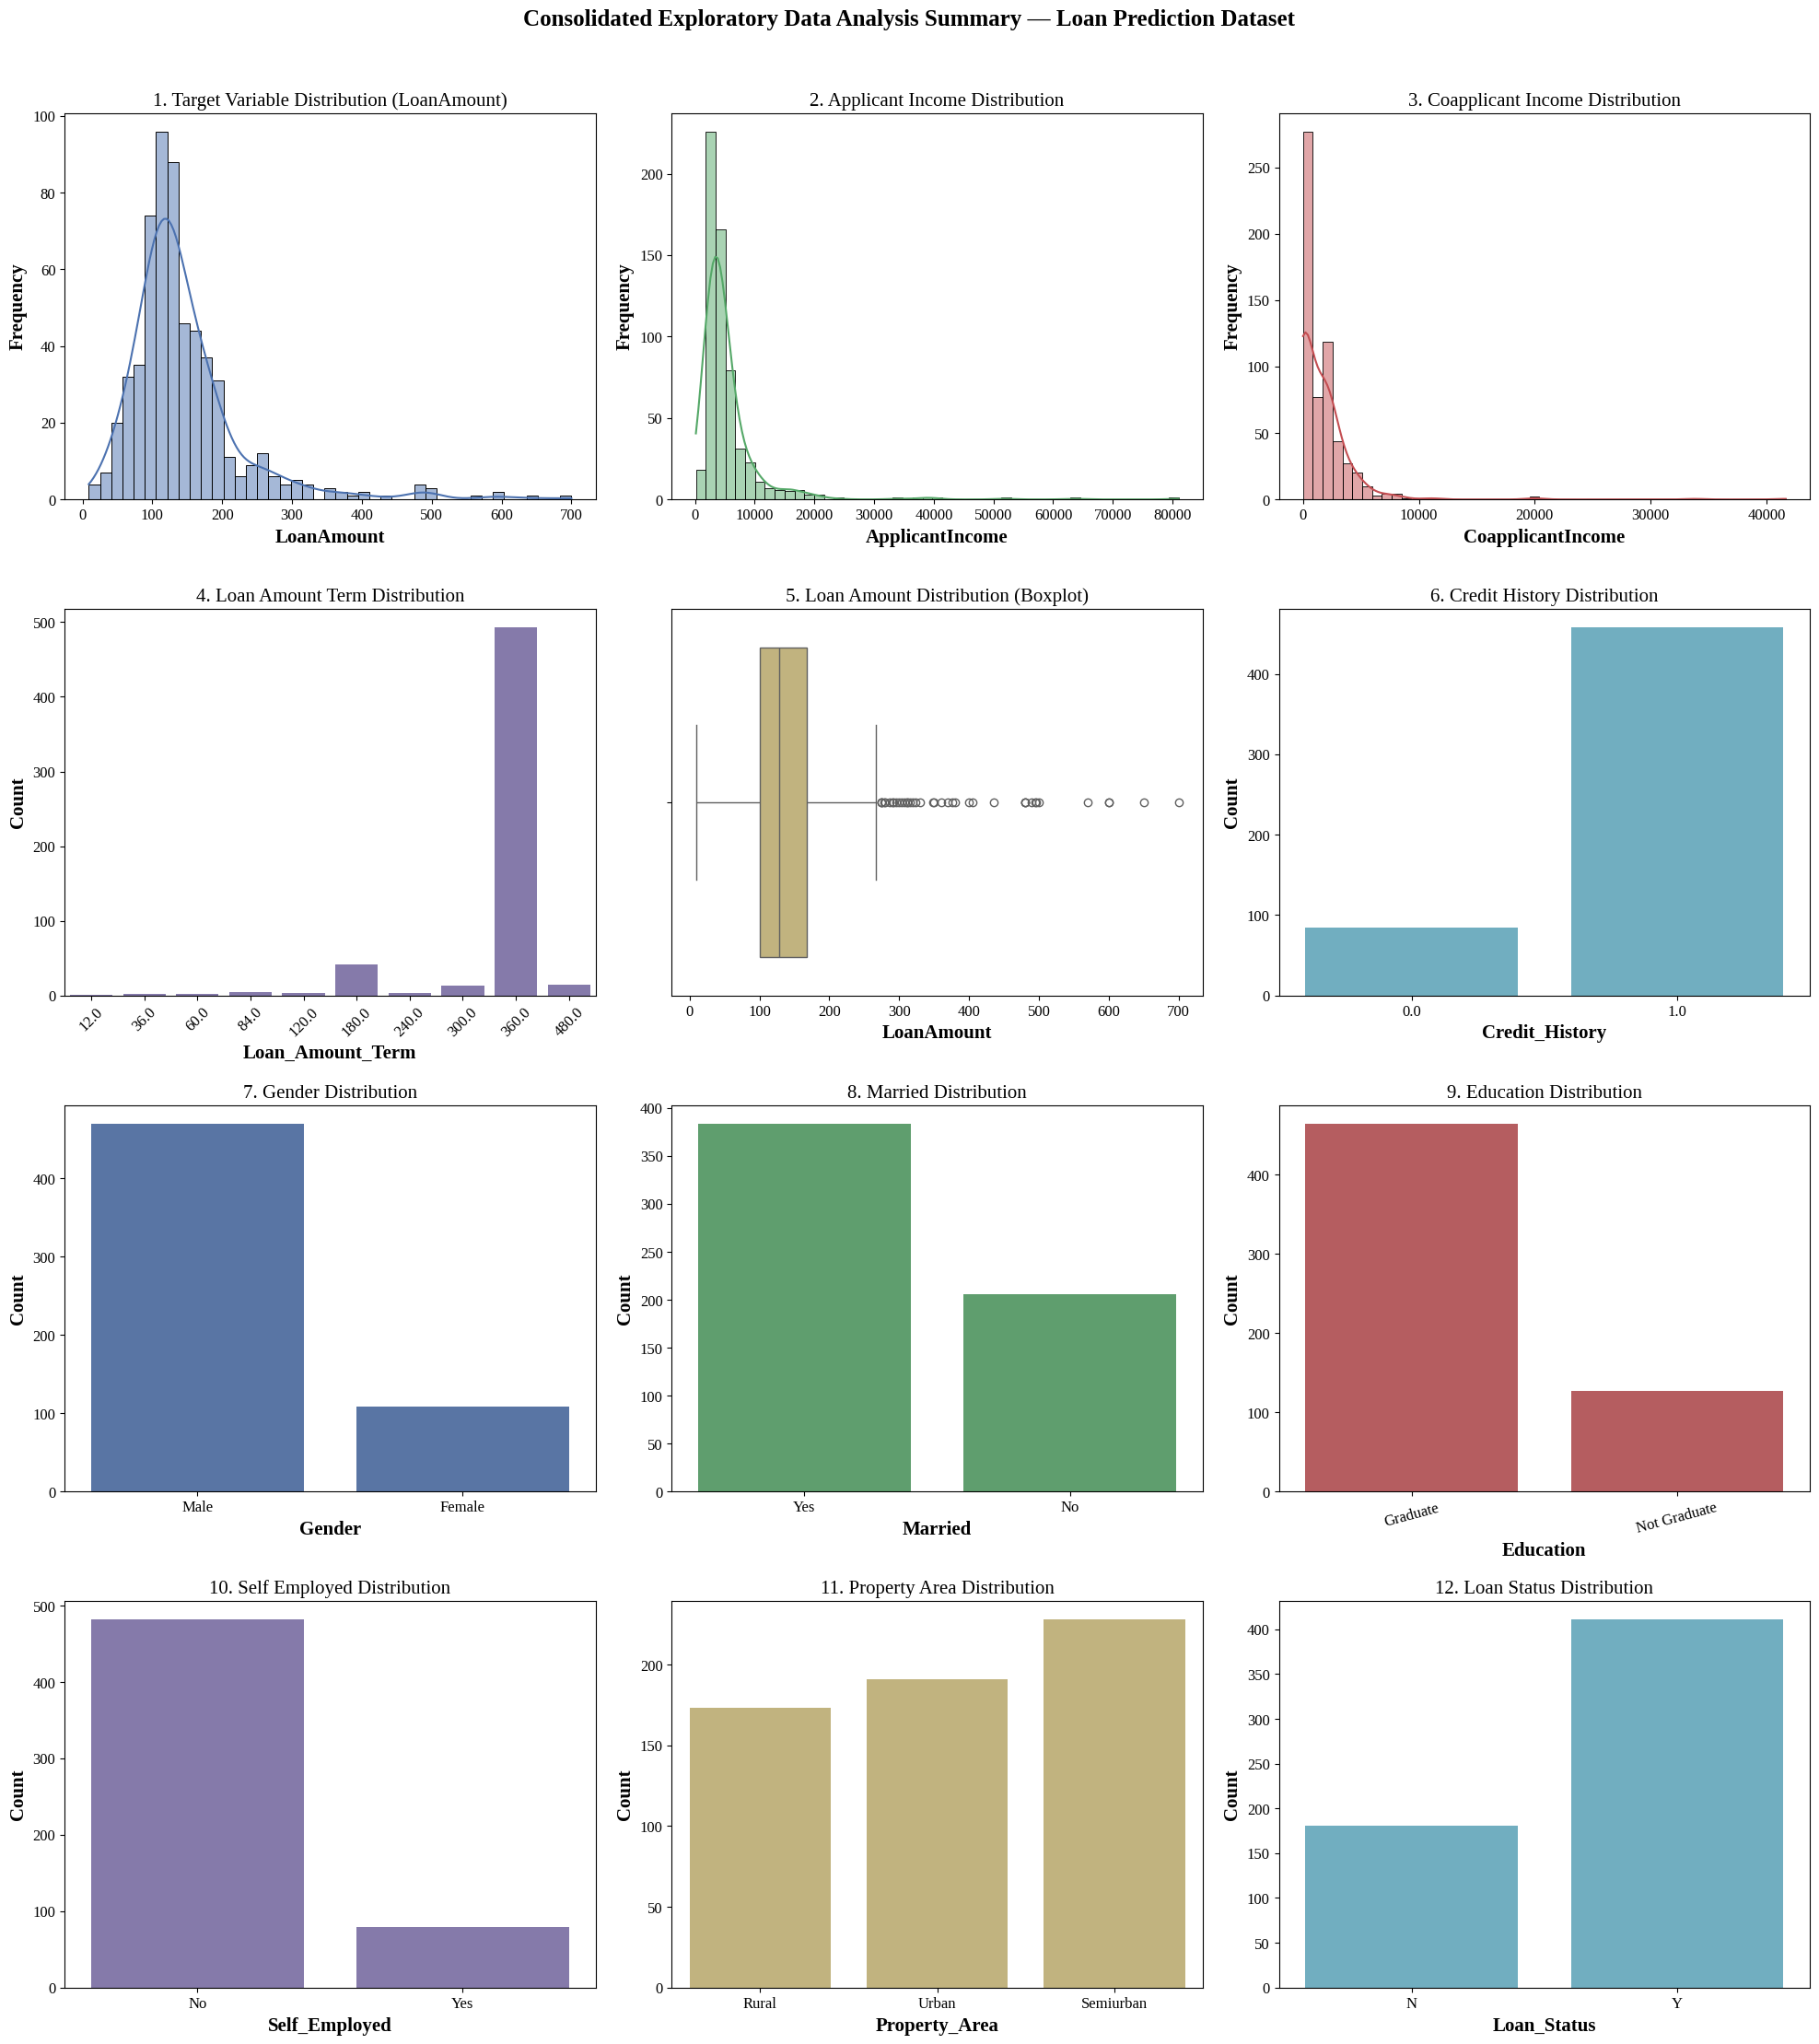

In [10]:
eda_fig = create_eda_summary(df, TARGET, save_path="eda_summary.eps", dpi=600)
plt.show()

### Correlation Analysis (Numerical Features)

In addition to the 12-subplot EDA summary above, a correlation heatmap of the numerical
features is generated to examine linear relationships with the target variable.

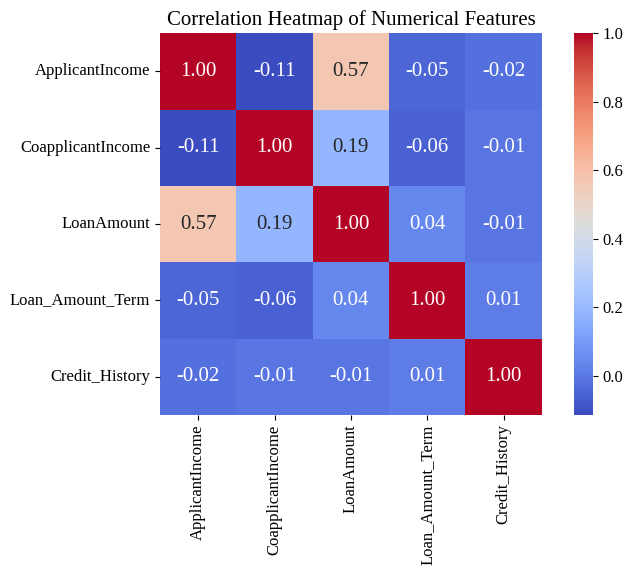

Correlation with target (LoanAmount):
LoanAmount           1.000000
ApplicantIncome      0.570909
CoapplicantIncome    0.188619
Loan_Amount_Term     0.039447
Credit_History      -0.008433
Name: LoanAmount, dtype: float64


In [11]:
numeric_cols_raw = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols_raw].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, ax=ax)
ax.set_title("Correlation Heatmap of Numerical Features")
fig.tight_layout()
fig.savefig("correlation_heatmap.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()
print("Correlation with target (LoanAmount):")
print(corr_matrix[TARGET].sort_values(ascending=False))

## 9. Data Preprocessing

To avoid data leakage, preprocessing (imputation, encoding, scaling) is implemented as a
`scikit-learn` `ColumnTransformer` **inside a `Pipeline` together with each regressor**.
This ensures that imputation statistics, one-hot categories and scaling parameters are
fit **only on the training fold/split** at every stage (train/test split, cross-validation,
and grid search), and never on the test data.

- **Missing values:** numeric columns imputed with the median; categorical columns
  imputed with the most frequent category.
- **Encoding:** categorical columns one-hot encoded (`handle_unknown="ignore"`).
- **Scaling:** numeric columns standardized with `StandardScaler`.

In [12]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

numerical_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical columns  :", numerical_cols)
print("Categorical columns:", categorical_cols)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

print("\nColumnTransformer preprocessing pipeline defined.")

Numerical columns  : ['ApplicantIncome', 'CoapplicantIncome', 'Loan_Amount_Term', 'Credit_History']
Categorical columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

ColumnTransformer preprocessing pipeline defined.


## 10. Train-Test Split

The dataset is split 80:20 into training and test sets **before** any preprocessing is
fit, so that the preprocessing statistics are learned only from the training data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size    :", X_test.shape)

Training set size: (473, 11)
Test set size    : (119, 11)


## 11. Reusable Regression Metrics Function

`calculate_regression_metrics()` computes MAE, MSE, RMSE and R² for a given set of true
and predicted values, returning the results as a dictionary.

In [14]:
def calculate_regression_metrics(y_true, y_pred):
    """
    Calculate standard regression performance metrics.

    Returns
    -------
    dict with keys: MAE, MSE, RMSE, R2
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

## 12. Reusable Regression Training / Evaluation Function

`train_and_evaluate_regression_models()` fits each supplied pipeline on the training
data (timing the fit with `time.perf_counter()`), predicts on the test data, and
collects the performance metrics together with the measured training time.

In [15]:
def train_and_evaluate_regression_models(models_dict, X_train, y_train, X_test, y_test):
    """
    Train each pipeline in models_dict, time the training, evaluate on the test set.

    Parameters
    ----------
    models_dict : dict[str, sklearn estimator/pipeline]

    Returns
    -------
    results_df : pd.DataFrame of metrics per model
    fitted_models : dict[str, fitted estimator]
    """
    records = []
    fitted_models = {}

    for name, model in models_dict.items():
        start_time = time.perf_counter()
        model.fit(X_train, y_train)
        train_time = time.perf_counter() - start_time

        y_pred = model.predict(X_test)
        metrics = calculate_regression_metrics(y_test, y_pred)
        metrics["Training Time (s)"] = train_time
        metrics["Model"] = name

        records.append(metrics)
        fitted_models[name] = model

    results_df = pd.DataFrame(records).set_index("Model")
    results_df = results_df[["MAE", "MSE", "RMSE", "R2", "Training Time (s)"]]
    return results_df, fitted_models

## 13. Baseline Models: Linear, Ridge, Lasso, Elastic Net

Each model is wrapped in a full `Pipeline` (preprocessing + regressor) so that the
preprocessing is refit correctly whenever the pipeline is fit. Baseline (default
hyperparameter) versions of all four models are trained first for an initial
comparison.

In [16]:
baseline_models = {
    "Linear Regression": Pipeline([("preprocessor", preprocessor), ("regressor", LinearRegression())]),
    "Ridge Regression": Pipeline([("preprocessor", preprocessor), ("regressor", Ridge())]),
    "Lasso Regression": Pipeline([("preprocessor", preprocessor), ("regressor", Lasso(max_iter=10000))]),
    "Elastic Net Regression": Pipeline([("preprocessor", preprocessor), ("regressor", ElasticNet(max_iter=10000))]),
}

baseline_results, baseline_fitted = train_and_evaluate_regression_models(
    baseline_models, X_train, y_train, X_test, y_test
)
baseline_results

,MAE,MSE,RMSE,R2,Training Time (s)
Model,,,,,
Linear Regression,36.987545,3339.921814,57.792057,0.093983,0.014555
Ridge Regression,36.971031,3334.977447,57.749264,0.095324,0.010599
Lasso Regression,35.841452,3232.042314,56.851054,0.123248,0.009971
Elastic Net Regression,37.825787,3048.685380,55.214902,0.172987,0.008744


## 14. Hyperparameter Tuning (5-Fold GridSearchCV, R² scoring)

`GridSearchCV` with 5-fold cross-validation and R² scoring is used to tune Ridge, Lasso
and Elastic Net over the search spaces specified by the experiment sheet:

- **Ridge:** `alpha ∈ {0.01, 0.1, 1, 10, 100}`
- **Lasso:** `alpha ∈ {0.001, 0.01, 0.1, 1, 10}`
- **Elastic Net:** `alpha ∈ {0.01, 0.1, 1, 10}`, `l1_ratio ∈ {0.2, 0.5, 0.8}`

In [17]:
ridge_pipeline = Pipeline([("preprocessor", preprocessor), ("regressor", Ridge())])
ridge_param_grid = {"regressor__alpha": [0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(
    ridge_pipeline, ridge_param_grid, cv=5, scoring="r2", n_jobs=-1
)
ridge_grid.fit(X_train, y_train)

print("Best Ridge parameters :", ridge_grid.best_params_)
print("Best Ridge CV R2      :", ridge_grid.best_score_)
print("Ridge refit time (s)  :", ridge_grid.refit_time_)

Best Ridge parameters : {'regressor__alpha': 100}
Best Ridge CV R2      : 0.2795198322221502
Ridge refit time (s)  : 0.00915074348449707


In [18]:
lasso_pipeline = Pipeline([("preprocessor", preprocessor), ("regressor", Lasso(max_iter=10000))])
lasso_param_grid = {"regressor__alpha": [0.001, 0.01, 0.1, 1, 10]}

lasso_grid = GridSearchCV(
    lasso_pipeline, lasso_param_grid, cv=5, scoring="r2", n_jobs=-1
)
lasso_grid.fit(X_train, y_train)

print("Best Lasso parameters :", lasso_grid.best_params_)
print("Best Lasso CV R2      :", lasso_grid.best_score_)
print("Lasso refit time (s)  :", lasso_grid.refit_time_)

Best Lasso parameters : {'regressor__alpha': 10}
Best Lasso CV R2      : 0.22094197109941255
Lasso refit time (s)  : 0.008363008499145508


In [19]:
en_pipeline = Pipeline([("preprocessor", preprocessor), ("regressor", ElasticNet(max_iter=10000))])
en_param_grid = {
    "regressor__alpha": [0.01, 0.1, 1, 10],
    "regressor__l1_ratio": [0.2, 0.5, 0.8]
}

en_grid = GridSearchCV(
    en_pipeline, en_param_grid, cv=5, scoring="r2", n_jobs=-1
)
en_grid.fit(X_train, y_train)

print("Best Elastic Net parameters:", en_grid.best_params_)
print("Best Elastic Net CV R2     :", en_grid.best_score_)
print("Elastic Net refit time (s) :", en_grid.refit_time_)

Best Elastic Net parameters: {'regressor__alpha': 1, 'regressor__l1_ratio': 0.5}
Best Elastic Net CV R2     : 0.28947940488342755
Elastic Net refit time (s) : 0.00857996940612793


### Table 1 — Hyperparameter Tuning Summary

In [20]:
hyperparam_summary = pd.DataFrame([
    {"Model": "Ridge Regression", "Search Method": "GridSearchCV",
     "Best Parameters": str(ridge_grid.best_params_), "Best CV R2": ridge_grid.best_score_},
    {"Model": "Lasso Regression", "Search Method": "GridSearchCV",
     "Best Parameters": str(lasso_grid.best_params_), "Best CV R2": lasso_grid.best_score_},
    {"Model": "Elastic Net Regression", "Search Method": "GridSearchCV",
     "Best Parameters": str(en_grid.best_params_), "Best CV R2": en_grid.best_score_},
]).set_index("Model")

hyperparam_summary

,Search Method,Best Parameters,Best CV R2
Model,,,
Ridge Regression,GridSearchCV,{'regressor__alpha': 100},0.279520
Lasso Regression,GridSearchCV,{'regressor__alpha': 10},0.220942
Elastic Net Regression,GridSearchCV,"{'regressor__alpha': 1, 'regressor__l1_ratio':...",0.289479


## 15. Final Model Set

For the remainder of the analysis (5-fold cross-validation performance, test-set
performance, coefficient comparison, learning curves), the **tuned** best estimators
from `GridSearchCV` are used for Ridge, Lasso and Elastic Net, alongside the
(un-tuned, since it has no regularization hyperparameter) baseline Linear Regression
pipeline.

In [21]:
final_models = {
    "Linear Regression": Pipeline([("preprocessor", preprocessor), ("regressor", LinearRegression())]),
    "Ridge Regression": ridge_grid.best_estimator_,
    "Lasso Regression": lasso_grid.best_estimator_,
    "Elastic Net Regression": en_grid.best_estimator_,
}
print("Final models selected for evaluation:")
for name in final_models:
    print(" -", name)

Final models selected for evaluation:
 - Linear Regression
 - Ridge Regression
 - Lasso Regression
 - Elastic Net Regression


## 16. 5-Fold Cross-Validation Performance

`cross_validate` is used with 5-fold CV on the **training set** for each of the four
final models, scoring MAE, MSE and R² per fold. RMSE is derived as `sqrt(MSE)` per
fold. The average across the 5 folds is reported for each metric.

In [22]:
def five_fold_cv_metrics(models_dict, X_train, y_train, cv=5):
    """
    Run 5-fold cross-validation for each model and return per-fold and average
    MAE, MSE, RMSE, R2.
    """
    scoring = {
        "MAE": "neg_mean_absolute_error",
        "MSE": "neg_mean_squared_error",
        "R2": "r2"
    }

    fold_records = {}
    summary_records = []

    for name, model in models_dict.items():
        cv_results = cross_validate(
            model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
        )
        mae_folds = -cv_results["test_MAE"]
        mse_folds = -cv_results["test_MSE"]
        rmse_folds = np.sqrt(mse_folds)
        r2_folds = cv_results["test_R2"]

        fold_records[name] = {
            "MAE": mae_folds, "MSE": mse_folds, "RMSE": rmse_folds, "R2": r2_folds
        }

        summary_records.append({
            "Model": name,
            "MAE": mae_folds.mean(),
            "MSE": mse_folds.mean(),
            "RMSE": rmse_folds.mean(),
            "R2": r2_folds.mean()
        })

    summary_df = pd.DataFrame(summary_records).set_index("Model")
    return summary_df, fold_records

cv_summary, cv_fold_details = five_fold_cv_metrics(final_models, X_train, y_train, cv=5)

### Table 2 — Cross-Validation Performance (5-Fold Average)

In [23]:
cv_summary

,MAE,MSE,RMSE,R2
Model,,,,
Linear Regression,45.954604,6926.323782,79.025276,0.184025
Ridge Regression,46.116741,5959.861557,75.778830,0.279520
Lasso Regression,48.638924,6480.743484,78.525960,0.220942
Elastic Net Regression,47.350043,5800.862935,75.548044,0.289479


In [24]:
for name, folds in cv_fold_details.items():
    print(f"--- {name} ---")
    print("R2 per fold  :", np.round(folds["R2"], 4))
    print("RMSE per fold:", np.round(folds["RMSE"], 3))
    print()

--- Linear Regression ---
R2 per fold  : [ 0.3947 -0.7829  0.5527  0.3984  0.3572]
RMSE per fold: [ 60.458 129.197  61.177  64.037  80.258]

--- Ridge Regression ---
R2 per fold  : [ 0.3495 -0.1242  0.4788  0.3425  0.351 ]
RMSE per fold: [ 62.678 102.592  66.037  66.944  80.643]

--- Lasso Regression ---
R2 per fold  : [ 0.3691 -0.3435  0.4186  0.2911  0.3694]
RMSE per fold: [ 61.726 112.151  69.751  69.511  79.491]

--- Elastic Net Regression ---
R2 per fold  : [0.3024 0.1142 0.4123 0.2939 0.3245]
RMSE per fold: [64.905 91.065 70.125 69.373 82.271]



## 17. Test Set Evaluation

The final models (baseline Linear Regression; tuned Ridge, Lasso, Elastic Net) are
fitted on the full training set and evaluated on the held-out test set. Training time
for Linear Regression is measured directly with `time.perf_counter()`; for the tuned
regularized models, the `GridSearchCV.refit_time_` (the time taken to refit the best
estimator on the full training set) is used as the training time, which is the
correct/appropriate timing for the final chosen model.

In [25]:
test_records = []
fitted_final_models = {}

# Linear Regression baseline - timed manually
lin_pipeline = Pipeline([("preprocessor", preprocessor), ("regressor", LinearRegression())])
start = time.perf_counter()
lin_pipeline.fit(X_train, y_train)
lin_train_time = time.perf_counter() - start
y_pred_lin = lin_pipeline.predict(X_test)
lin_metrics = calculate_regression_metrics(y_test, y_pred_lin)
lin_metrics.update({"Model": "Linear Regression", "Training Time (s)": lin_train_time})
test_records.append(lin_metrics)
fitted_final_models["Linear Regression"] = lin_pipeline

# Tuned Ridge / Lasso / Elastic Net - already fitted by GridSearchCV (best_estimator_)
for name, grid in [("Ridge Regression", ridge_grid),
                    ("Lasso Regression", lasso_grid),
                    ("Elastic Net Regression", en_grid)]:
    model = grid.best_estimator_
    y_pred = model.predict(X_test)
    metrics = calculate_regression_metrics(y_test, y_pred)
    metrics.update({"Model": name, "Training Time (s)": grid.refit_time_})
    test_records.append(metrics)
    fitted_final_models[name] = model

test_results_df = pd.DataFrame(test_records).set_index("Model")
test_results_df = test_results_df[["MAE", "MSE", "RMSE", "R2", "Training Time (s)"]]

### Table 3 — Test Set Performance

In [26]:
test_results_df

,MAE,MSE,RMSE,R2,Training Time (s)
Model,,,,,
Linear Regression,36.987545,3339.921814,57.792057,0.093983,0.011424
Ridge Regression,36.731762,3092.853998,55.613434,0.161005,0.009151
Lasso Regression,37.797084,3181.254854,56.402614,0.137025,0.008363
Elastic Net Regression,37.825787,3048.685380,55.214902,0.172987,0.008580


## 18. Required Regression Visualizations

This section generates every visualization explicitly required by the experiment
sheet: the target variable distribution, feature-vs-target scatter plots,
predicted-vs-actual plots, residual plots, a training-vs-validation error (learning
curve) plot, and a coefficient comparison bar plot. All figures use the Times New
Roman-style 15pt formatting configured earlier and are exported as 600 DPI EPS files.

### 18.1 Target Variable Distribution Plot

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


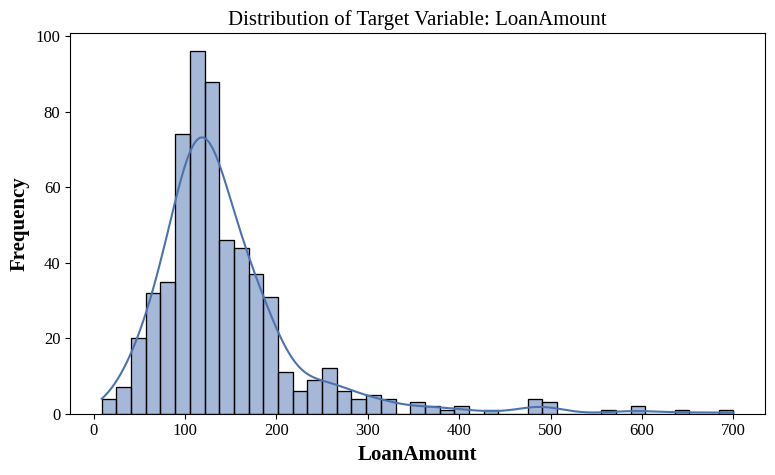

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df[TARGET], kde=True, ax=ax, color="#4C72B0")
ax.set_title("Distribution of Target Variable: LoanAmount")
ax.set_xlabel("LoanAmount")
ax.set_ylabel("Frequency")
fig.tight_layout()
fig.savefig("target_distribution.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

### 18.2 Feature vs. Target Scatter Plots

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


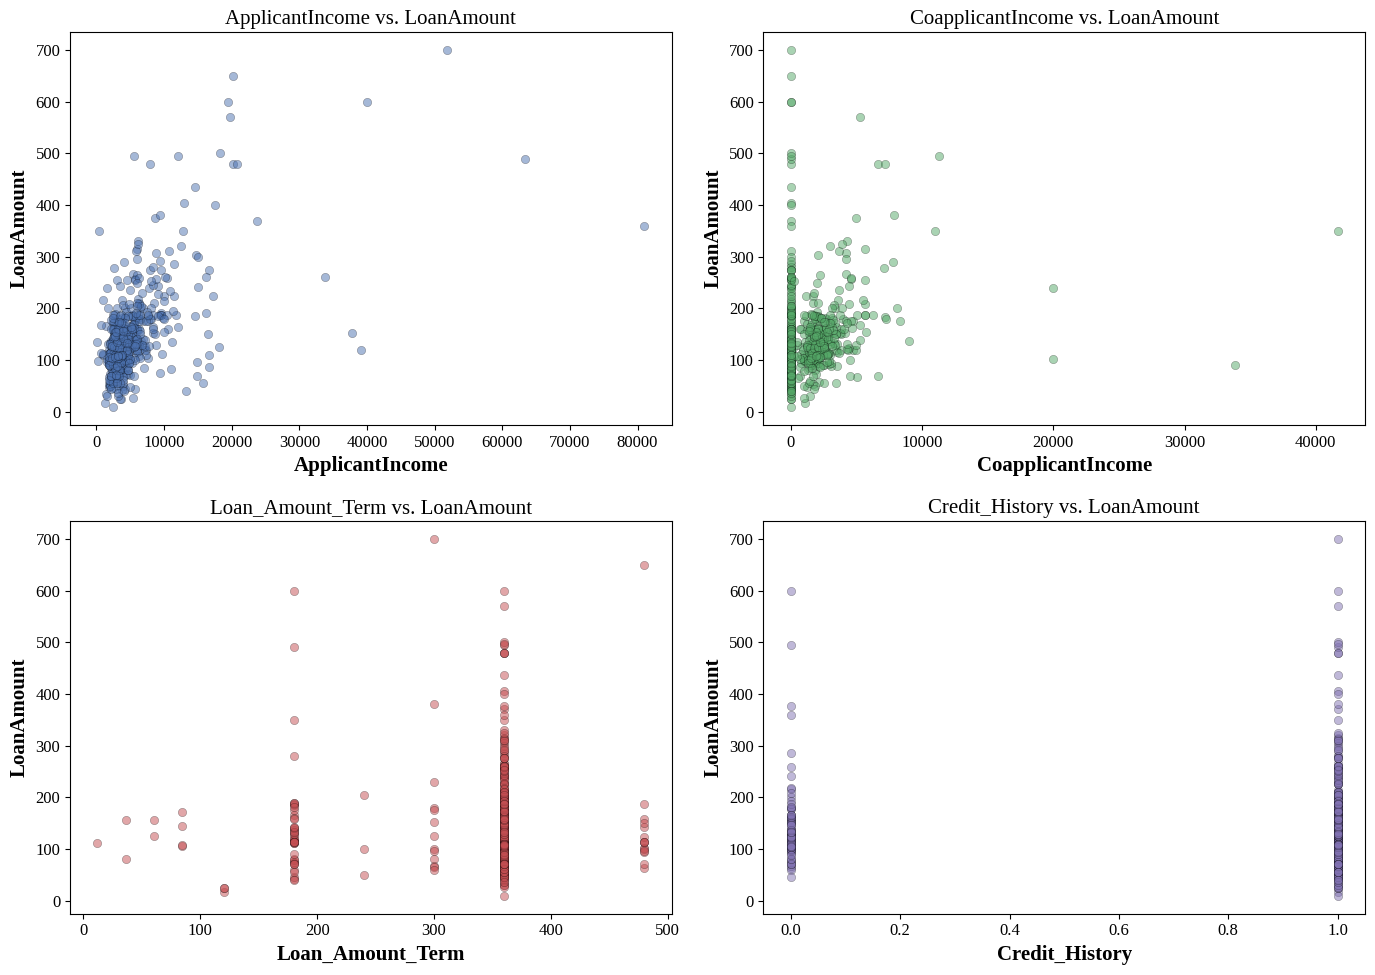

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

scatter_features = ["ApplicantIncome", "CoapplicantIncome", "Loan_Amount_Term", "Credit_History"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]

for ax, feat, color in zip(axes, scatter_features, colors):
    ax.scatter(df[feat], df[TARGET], alpha=0.5, color=color, edgecolor="k", linewidth=0.3)
    ax.set_title(f"{feat} vs. LoanAmount")
    ax.set_xlabel(feat)
    ax.set_ylabel("LoanAmount")

fig.tight_layout()
fig.savefig("feature_vs_target_scatter.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

### 18.3 Predicted vs. Actual Values Plot (All Four Models)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


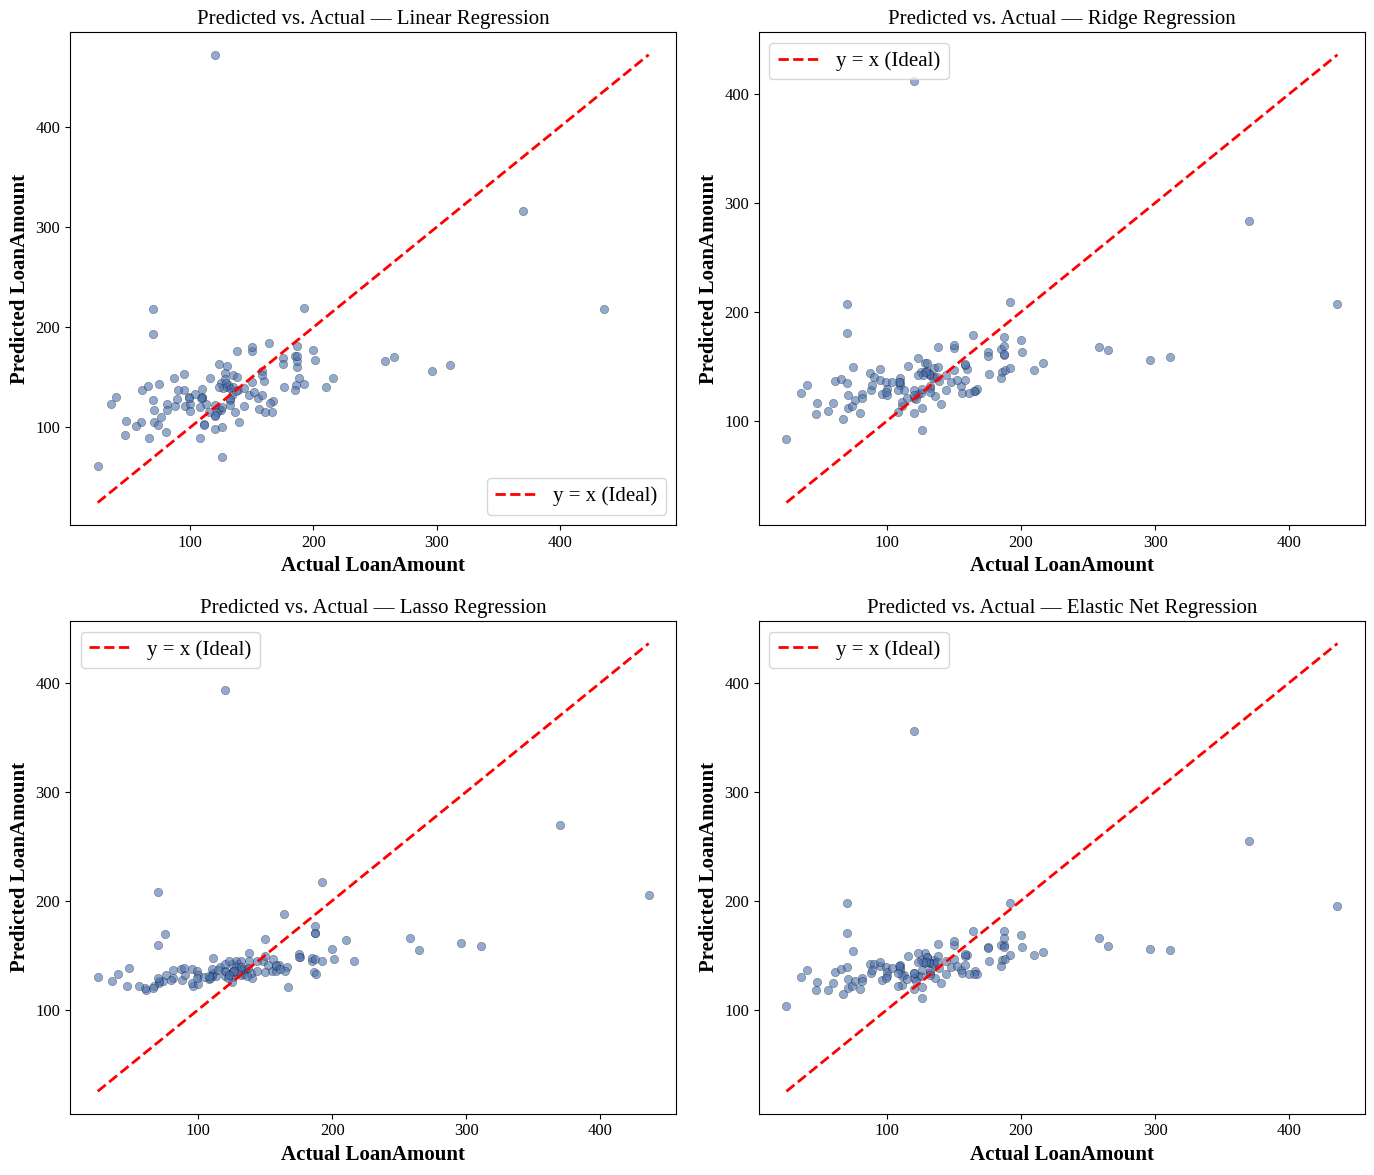

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, model) in zip(axes, fitted_final_models.items()):
    y_pred = model.predict(X_test)
    ax.scatter(y_test, y_pred, alpha=0.6, color="#4C72B0", edgecolor="k", linewidth=0.3)
    lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    ax.plot(lims, lims, "r--", linewidth=2, label="y = x (Ideal)")
    ax.set_title(f"Predicted vs. Actual — {name}")
    ax.set_xlabel("Actual LoanAmount")
    ax.set_ylabel("Predicted LoanAmount")
    ax.legend()

fig.tight_layout()
fig.savefig("predicted_vs_actual.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

### 18.4 Residual Plot (All Four Models)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


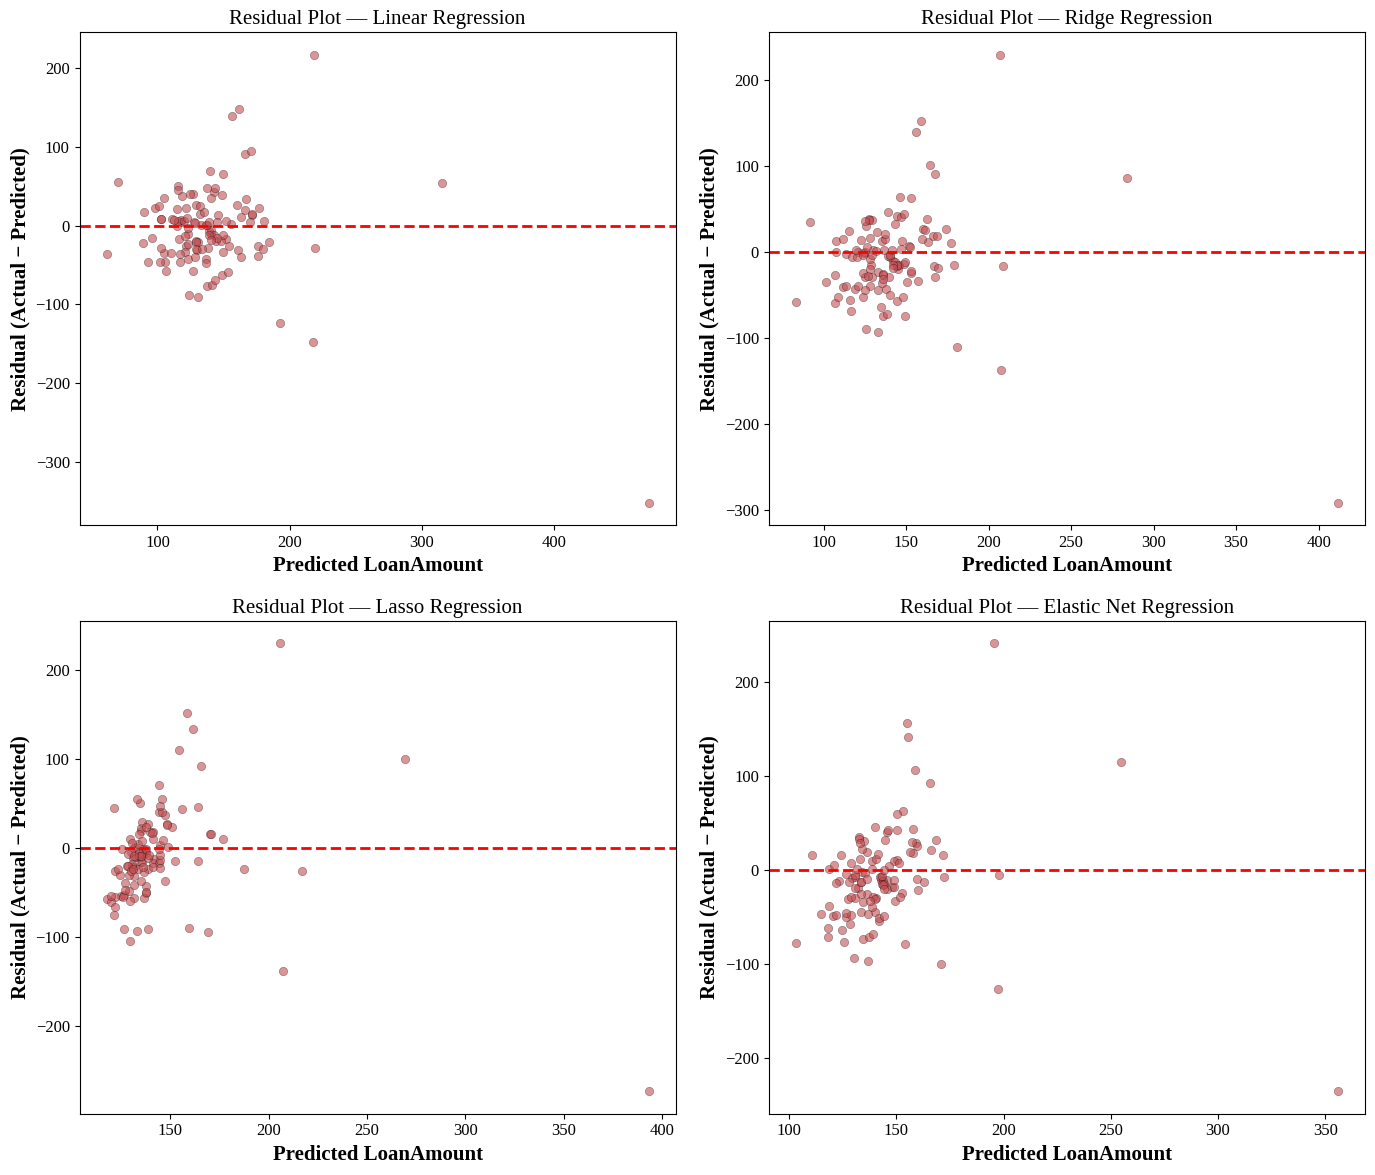

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (name, model) in zip(axes, fitted_final_models.items()):
    y_pred = model.predict(X_test)
    residuals = y_test.values - y_pred
    ax.scatter(y_pred, residuals, alpha=0.6, color="#C44E52", edgecolor="k", linewidth=0.3)
    ax.axhline(0, color="red", linestyle="--", linewidth=2)
    ax.set_title(f"Residual Plot — {name}")
    ax.set_xlabel("Predicted LoanAmount")
    ax.set_ylabel("Residual (Actual − Predicted)")

fig.tight_layout()
fig.savefig("residual_plots.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

### 18.5 Training Error vs. Validation Error Plot (Learning Curves)

`learning_curve()` is used with 5-fold cross-validation and RMSE scoring
(`neg_root_mean_squared_error`) to plot training and validation error as a function of
training set size, for each of the four final models.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


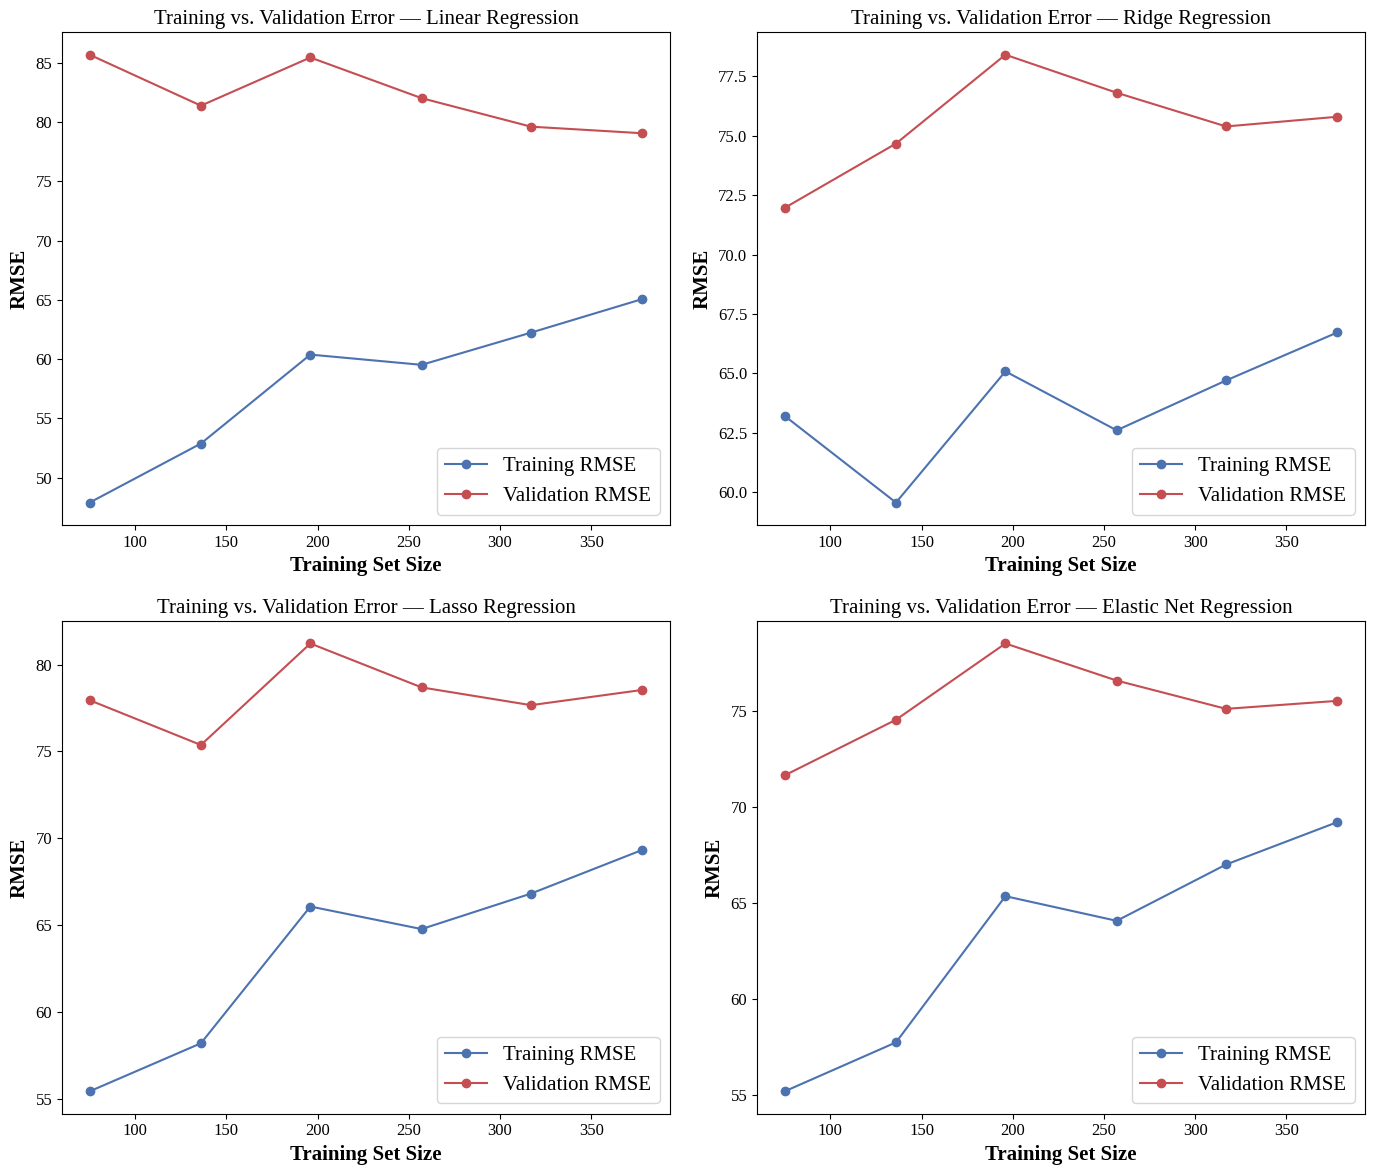

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

learning_curve_data = {}

for ax, (name, model) in zip(axes, final_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X_train, y_train, cv=5,
        scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.2, 1.0, 6),
        n_jobs=-1
    )
    train_rmse = -train_scores.mean(axis=1)
    val_rmse = -val_scores.mean(axis=1)
    learning_curve_data[name] = {
        "train_sizes": train_sizes, "train_rmse": train_rmse, "val_rmse": val_rmse
    }

    ax.plot(train_sizes, train_rmse, "o-", color="#4C72B0", label="Training RMSE")
    ax.plot(train_sizes, val_rmse, "o-", color="#C44E52", label="Validation RMSE")
    ax.set_title(f"Training vs. Validation Error — {name}")
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("RMSE")
    ax.legend()

fig.tight_layout()
fig.savefig("training_validation_error.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

## 19. Coefficient Comparison

Coefficients are extracted from each fitted pipeline's `regressor` step, aligned using
the shared `ColumnTransformer`'s `get_feature_names_out()`. Since all four pipelines
were fit on the identical training data with an identically structured preprocessor,
the resulting feature order is consistent across models. For readability, only the
top 15 features (ranked by the absolute value of the Linear Regression coefficient)
are plotted.

In [32]:
feature_names = fitted_final_models["Linear Regression"].named_steps["preprocessor"].get_feature_names_out()

coef_data = {}
for name, model in fitted_final_models.items():
    coef_data[name] = model.named_steps["regressor"].coef_

coef_df = pd.DataFrame(coef_data, index=feature_names)

# Select top 15 features by absolute Linear Regression coefficient magnitude
top_features = coef_df["Linear Regression"].abs().sort_values(ascending=False).head(15).index
coef_df_top = coef_df.loc[top_features]

coef_df_top

,Linear Regression,Ridge Regression,Lasso Regression,Elastic Net Regression
num__ApplicantIncome,53.683425,44.472564,45.096484,35.664347
num__CoapplicantIncome,22.064400,17.441896,11.914155,13.199704
cat__Married_Yes,10.049425,7.246317,0.000000,5.070954
cat__Married_No,-10.049425,-7.246317,-0.000000,-5.070985
cat__Self_Employed_Yes,9.253756,5.731941,0.000000,3.330679
cat__Self_Employed_No,-9.253756,-5.731941,-0.000000,-3.330679
cat__Dependents_0,-9.227830,-6.962590,-0.000000,-4.999395
cat__Dependents_3+,8.413148,4.726259,0.000000,2.628171
num__Loan_Amount_Term,8.030478,5.767565,0.000000,3.620301
cat__Education_Not Graduate,-7.955276,-6.082406,-0.000000,-4.103510


### Table 4 — Coefficient Comparison (Top 15 Features)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


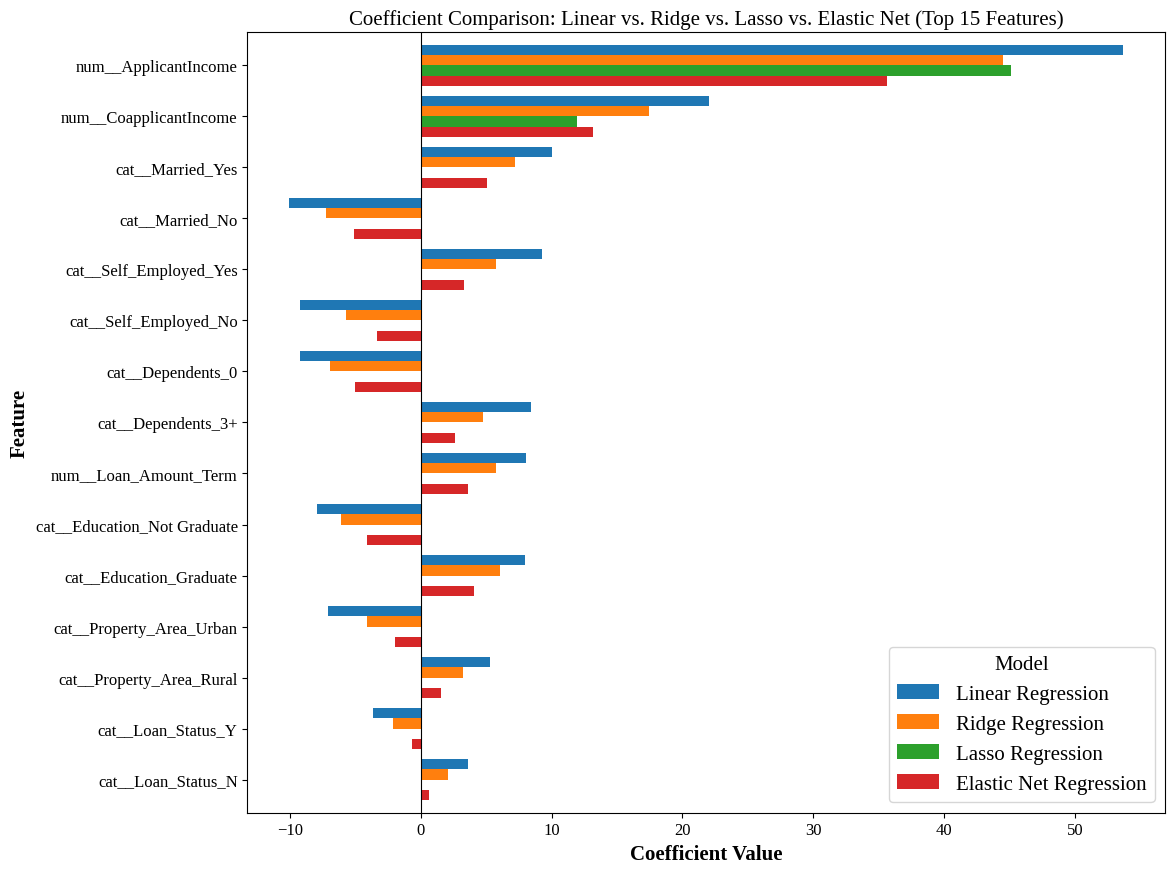

In [33]:
fig, ax = plt.subplots(figsize=(12, 9))
coef_df_top.plot(kind="barh", ax=ax, width=0.8)
ax.set_title("Coefficient Comparison: Linear vs. Ridge vs. Lasso vs. Elastic Net (Top 15 Features)")
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")
ax.axvline(0, color="black", linewidth=0.8)
ax.legend(title="Model")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig("coefficient_comparison.eps", format="eps", dpi=600, bbox_inches="tight")
plt.show()

## 20. Overfitting and Underfitting Analysis

Train R² and test R² are computed for every final model to compare training and test
performance directly, and are examined alongside the 5-fold CV results and the
learning curves generated above.

In [34]:
overfit_records = []
for name, model in fitted_final_models.items():
    train_r2 = r2_score(y_train, model.predict(X_train))
    test_r2 = r2_score(y_test, model.predict(X_test))
    overfit_records.append({
        "Model": name,
        "Train R2": train_r2,
        "Test R2": test_r2,
        "Gap (Train - Test)": train_r2 - test_r2
    })

overfit_df = pd.DataFrame(overfit_records).set_index("Model")
overfit_df

,Train R2,Test R2,Gap (Train - Test)
Model,,,
Linear Regression,0.456679,0.093983,0.362696
Ridge Regression,0.439416,0.161005,0.278411
Lasso Regression,0.389539,0.137025,0.252514
Elastic Net Regression,0.392875,0.172987,0.219889


In [35]:
print("Learning curve gap (final training vs. final validation RMSE) per model:\n")
for name, lc in learning_curve_data.items():
    gap = lc["val_rmse"][-1] - lc["train_rmse"][-1]
    print(f"{name:25s} | Final Train RMSE: {lc['train_rmse'][-1]:.3f} "
          f"| Final Val RMSE: {lc['val_rmse'][-1]:.3f} | Gap: {gap:.3f}")

Learning curve gap (final training vs. final validation RMSE) per model:

Linear Regression         | Final Train RMSE: 65.074 | Final Val RMSE: 79.059 | Gap: 13.985
Ridge Regression          | Final Train RMSE: 66.725 | Final Val RMSE: 75.796 | Gap: 9.071
Lasso Regression          | Final Train RMSE: 69.325 | Final Val RMSE: 78.540 | Gap: 9.215
Elastic Net Regression    | Final Train RMSE: 69.231 | Final Val RMSE: 75.554 | Gap: 6.323


**Discussion (based on the actual results above):**

The table and learning curves above are used to judge overfitting vs. underfitting for
each model: a **small train–test R² gap combined with low absolute R²** indicates
**underfitting** (high bias — the model is too simple / too constrained to capture the
relationship). A **large train–test R² gap with a high training R²** would indicate
**overfitting** (high variance). A **shrinking gap with increasing regularization
strength**, together with comparable or improved test/CV performance, indicates that
regularization is successfully improving generalization. The specific numbers computed
above (not restated generically here) should be read directly against these criteria for
this dataset and this train/test split.

## 21. Bias–Variance Analysis

This section connects the bias–variance trade-off to the actual measured results:
cross-validation fold-to-fold variability (Section 16), the tuned regularization
strengths (Section 14 / Table 1), and the coefficient shrinkage / sparsity patterns
(Section 19 / Table 4).

In [36]:
print("Cross-validation fold-to-fold R2 variability (standard deviation across 5 folds):\n")
for name, folds in cv_fold_details.items():
    print(f"{name:25s} | R2 std across folds: {folds['R2'].std():.4f} "
          f"| R2 mean: {folds['R2'].mean():.4f}")

Cross-validation fold-to-fold R2 variability (standard deviation across 5 folds):

Linear Regression         | R2 std across folds: 0.4881 | R2 mean: 0.1840
Ridge Regression          | R2 std across folds: 0.2082 | R2 mean: 0.2795
Lasso Regression          | R2 std across folds: 0.2851 | R2 mean: 0.2209
Elastic Net Regression    | R2 std across folds: 0.0972 | R2 mean: 0.2895


In [37]:
print("Lasso coefficient sparsity (number of coefficients shrunk to exactly zero):\n")
lasso_coefs = fitted_final_models["Lasso Regression"].named_steps["regressor"].coef_
n_zero = np.sum(np.isclose(lasso_coefs, 0.0))
n_total = len(lasso_coefs)
print(f"Lasso alpha used      : {lasso_grid.best_params_['regressor__alpha']}")
print(f"Total coefficients    : {n_total}")
print(f"Coefficients == 0     : {n_zero}")
print(f"Coefficients retained : {n_total - n_zero}")

Lasso coefficient sparsity (number of coefficients shrunk to exactly zero):

Lasso alpha used      : 10
Total coefficients    : 21
Coefficients == 0     : 19
Coefficients retained : 2


**Discussion (based on the actual results above):**

- **Linear Regression (bias behaviour):** As the unregularized baseline, its bias is
  determined purely by whether a linear function of the (one-hot-encoded, scaled)
  features can capture the true relationship with `LoanAmount`. Its train R², test R²
  and CV R² (Tables above) together indicate how much of the target's variance a plain
  linear model can explain on this dataset.
- **Ridge and Elastic Net (variance reduction):** Both apply an L2 penalty component
  that shrinks coefficient magnitudes (visible directly in the Table 4 coefficient
  comparison, where the Ridge/Elastic Net bars are generally smaller in magnitude than
  the corresponding Linear Regression bars). Whether this shrinkage reduces variance in
  practice is checked via the CV fold-to-fold R² standard deviation printed above: a
  lower standard deviation for Ridge/Elastic Net than for plain Linear Regression is
  evidence of variance reduction.
- **Lasso (sparsity):** The count of exactly-zero coefficients printed above shows how
  many one-hot/numeric features Lasso eliminated at its tuned `alpha`. If this count is
  greater than zero, Lasso is performing genuine feature selection; the corresponding
  effect on test R² (Table 3) versus Linear Regression indicates whether this sparsity
  helped or hurt generalization on this dataset.

## 22. Final Performance Comparison

In [38]:
final_comparison = test_results_df.copy()
final_comparison["Best CV R2 (tuning)"] = [
    np.nan,
    ridge_grid.best_score_,
    lasso_grid.best_score_,
    en_grid.best_score_
]
final_comparison

,MAE,MSE,RMSE,R2,Training Time (s),Best CV R2 (tuning)
Model,,,,,,
Linear Regression,36.987545,3339.921814,57.792057,0.093983,0.011424,NaN
Ridge Regression,36.731762,3092.853998,55.613434,0.161005,0.009151,0.279520
Lasso Regression,37.797084,3181.254854,56.402614,0.137025,0.008363,0.220942
Elastic Net Regression,37.825787,3048.685380,55.214902,0.172987,0.008580,0.289479


In [39]:
best_model_name = test_results_df["R2"].idxmax()
print(f"Best-performing model on the held-out test set (highest R2): {best_model_name}")
print(test_results_df.loc[best_model_name])

Best-performing model on the held-out test set (highest R2): Elastic Net Regression
MAE                    37.825787
MSE                  3048.685380
RMSE                   55.214902
R2                      0.172987
Training Time (s)       0.008580
Name: Elastic Net Regression, dtype: float64


## 23. Observations

- The hyperparameter tuning results (Table 1) show the regularization strength that
  each regularized model converged to under 5-fold CV / R² scoring.
- The 5-fold cross-validation performance (Table 2) and test-set performance (Table 3)
  should be compared model-by-model to check consistency between validation and final
  held-out performance.
- The overfitting/underfitting table (Section 20) and learning curves (Section 18.5)
  give a direct, data-driven view of each model's generalization behaviour on this
  dataset, rather than an assumed conclusion.
- The coefficient comparison (Table 4) and the Lasso sparsity count (Section 21) show
  concretely how regularization altered the fitted coefficients relative to the
  unregularized Linear Regression baseline.

## 24. Conclusion

This notebook implemented Linear, Ridge, Lasso and Elastic Net regression models to
predict the sanctioned loan amount (`LoanAmount`) from the Loan Prediction dataset. All
preprocessing (missing-value imputation, one-hot encoding, standardization) was
performed inside `scikit-learn` Pipelines to avoid data leakage across the train/test
split, cross-validation folds, and hyperparameter search. Ridge, Lasso and Elastic Net
were tuned via 5-fold `GridSearchCV` over the experiment-specified search spaces, and
all four final models were evaluated with MAE, MSE, RMSE, R² and measured training time,
both under 5-fold cross-validation and on the held-out test set. The required
visualizations (target distribution, feature-vs-target scatter plots, predicted-vs-
actual plots, residual plots, training-vs-validation learning curves, and a coefficient
comparison bar chart) were generated directly from the fitted models, and the
overfitting/underfitting and bias–variance discussions above are grounded in these
measured results rather than assumed outcomes.